In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [4]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [5]:
df.isnull().sum()

,0
carbon_fiber_fraction,0
epoxy_resin_fraction,0
volume_fraction,0
strength_MPa,0
stiffness_GPa,0
toughness_MJ_per_m3,0


In [6]:
# 2. Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [7]:
# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 4. Train Random Forest Model
# n_estimators=100 means we are using 100 individual decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
# 5. Predict and Evaluate
y_pred = rf_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

R2 Score: 0.9301
MAE: 30.55 MPa
MSE: 1461.69


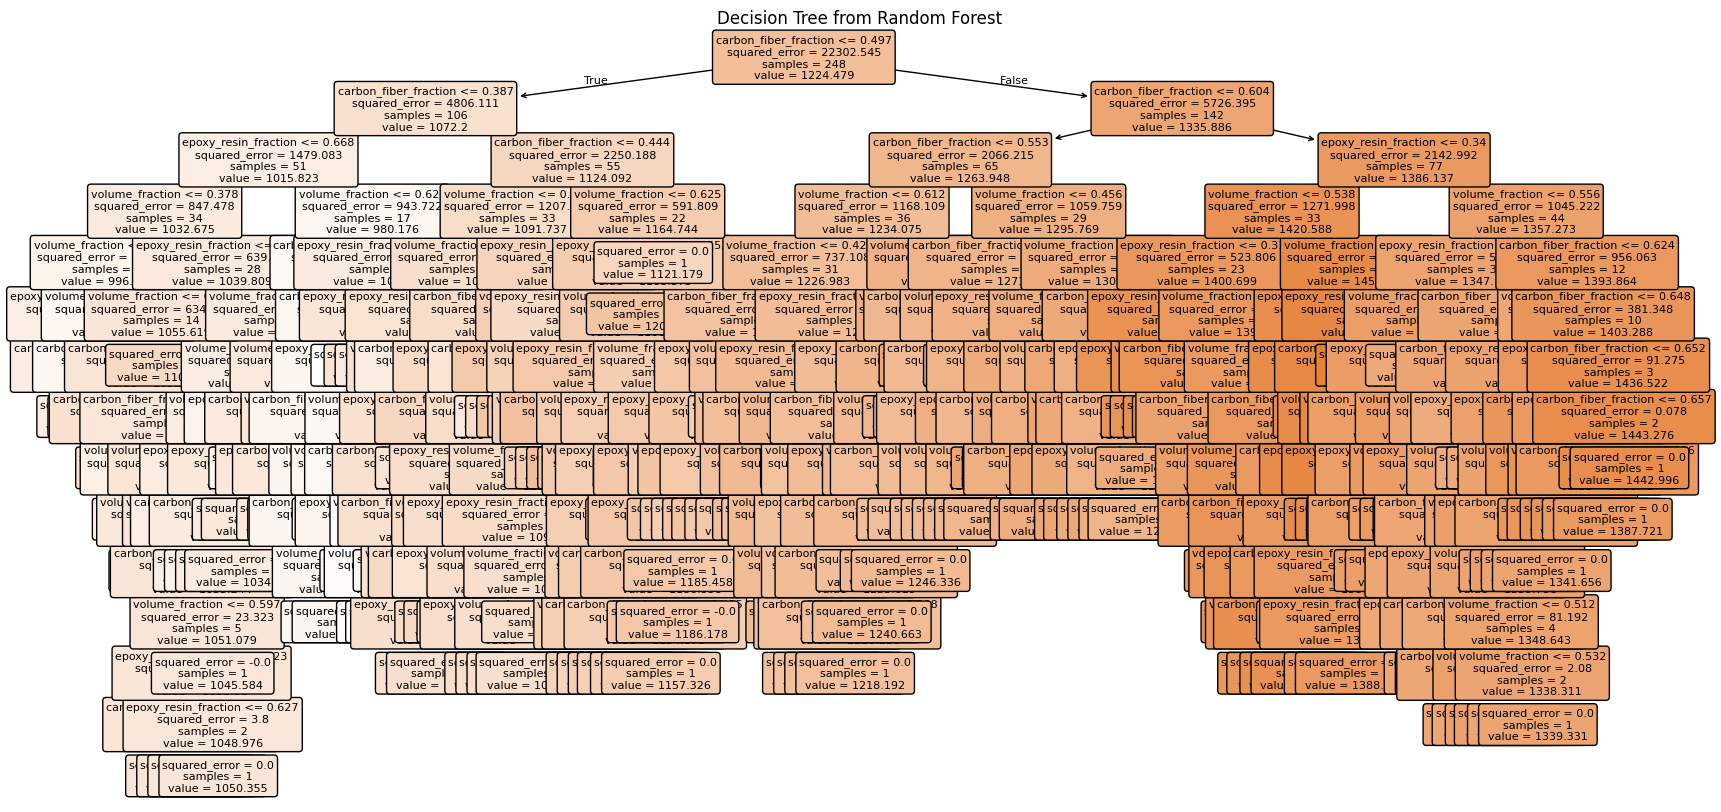

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Select the first tree from the Random Forest model for visualization
tree_to_visualize = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree_to_visualize,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree from Random Forest")
plt.show()

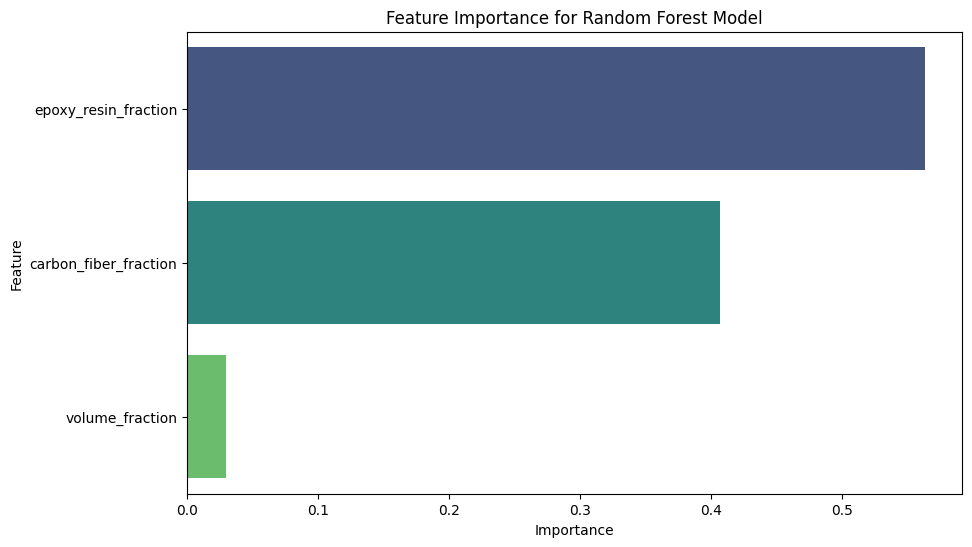

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Create a pandas Series for better visualization with feature names
importance_df = pd.Series(feature_importances, index=X.columns).sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df.values, y=importance_df.index, hue=importance_df.index, palette='viridis', legend=False)
plt.title('Feature Importance for Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores)
print(f"Mean R2 score: {cv_scores.mean():.4f}")
print(f"Standard deviation of R2 scores: {cv_scores.std():.4f}")

Cross-validation R2 scores: [0.9520089  0.93921121 0.94388567 0.93890181 0.95917173]
Mean R2 score: 0.9466
Standard deviation of R2 scores: 0.0079


In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None],  # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None]  # Maximum depth of the tree
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score found: ", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best R2 score found:  0.9520923028680086


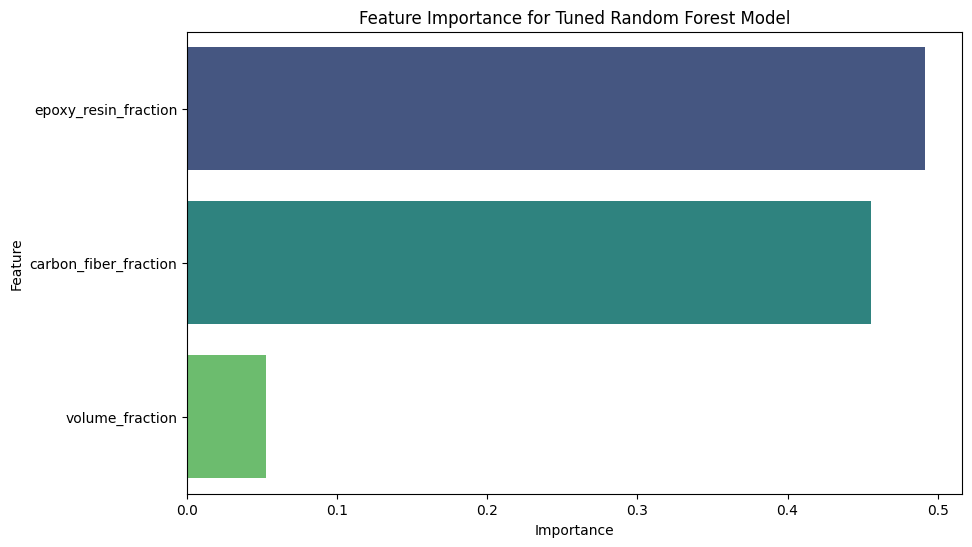

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from the grid search
best_rf_model = grid_search.best_estimator_

# Get feature importances from the best trained Random Forest model
feature_importances_tuned = best_rf_model.feature_importances_

# Create a pandas Series for better visualization with feature names
importance_df_tuned = pd.Series(feature_importances_tuned, index=X.columns).sort_values(ascending=False)

# Create the bar plot for the tuned model
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df_tuned.values, y=importance_df_tuned.index, hue=importance_df_tuned.index, palette='viridis', legend=False)
plt.title('Feature Importance for Tuned Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [20]:
# Generate some new sample data for prediction
# For demonstration, let's create a DataFrame with similar column names
new_data = pd.DataFrame({
    'carbon_fiber_fraction': [0.5, 0.7, 0.4],
    'epoxy_resin_fraction': [0.5, 0.3, 0.6],
    'volume_fraction': [0.5, 0.6, 0.45]
})

print("New Data for Prediction:")
display(new_data)

# Predict the 'strength_MPa' for the new data using the best_rf_model
new_predictions = best_rf_model.predict(new_data)

print("\nPredicted Strength (MPa) for New Data:")
for i, pred in enumerate(new_predictions):
    print(f"Sample {i+1}: {pred:.2f} MPa")

New Data for Prediction:


,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction
0,0.5,0.5,0.50
1,0.7,0.3,0.60
2,0.4,0.6,0.45



Predicted Strength (MPa) for New Data:
Sample 1: 1220.18 MPa
Sample 2: 1463.28 MPa
Sample 3: 1075.26 MPa


### Feature Importance for `stiffness_GPa`

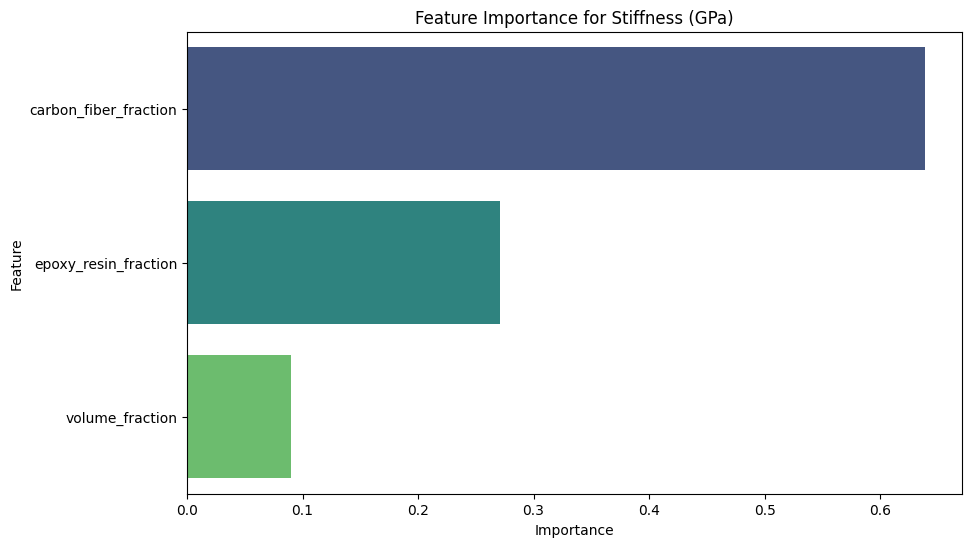

In [21]:
# Set y to stiffness_GPa
y_stiffness = df['stiffness_GPa']

# Split data for stiffness_GPa
X_train_stiffness, X_test_stiffness, y_train_stiffness, y_test_stiffness = train_test_split(X, y_stiffness, test_size=0.2, random_state=42)

# Train a new Random Forest model for stiffness_GPa
rf_model_stiffness = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_stiffness.fit(X_train_stiffness, y_train_stiffness)

# Get feature importances
feature_importances_stiffness = rf_model_stiffness.feature_importances_
importance_df_stiffness = pd.Series(feature_importances_stiffness, index=X.columns).sort_values(ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df_stiffness.values, y=importance_df_stiffness.index, hue=importance_df_stiffness.index, palette='viridis', legend=False)
plt.title('Feature Importance for Stiffness (GPa)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Feature Importance for `toughness_MJ_per_m3`

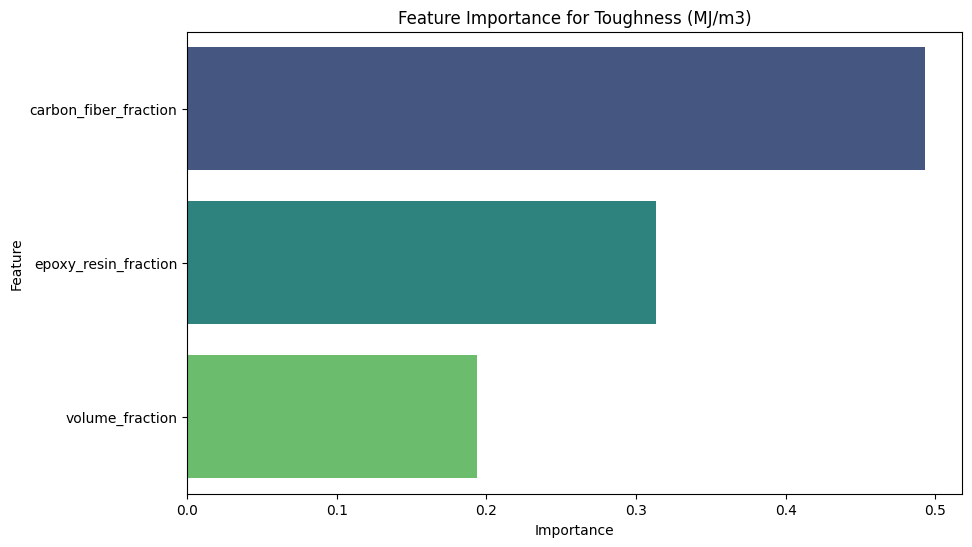

In [22]:
# Set y to toughness_MJ_per_m3
y_toughness = df['toughness_MJ_per_m3']

# Split data for toughness_MJ_per_m3
X_train_toughness, X_test_toughness, y_train_toughness, y_test_toughness = train_test_split(X, y_toughness, test_size=0.2, random_state=42)

# Train a new Random Forest model for toughness_MJ_per_m3
rf_model_toughness = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_toughness.fit(X_train_toughness, y_train_toughness)

# Get feature importances
feature_importances_toughness = rf_model_toughness.feature_importances_
importance_df_toughness = pd.Series(feature_importances_toughness, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df_toughness.values, y=importance_df_toughness.index, hue=importance_df_toughness.index, palette='viridis', legend=False)
plt.title('Feature Importance for Toughness (MJ/m3)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()